In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
np.seterr(all = 'ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
rand_walk_vec = []
for j in range(5):
    rw = generate_rw(1000, np.random.uniform(1, 20))
    ent_rates = []
    for i in range(3, 11):
        ent_rates.append(permutation_entropy_rate(rw, i))
    rand_walk_vec.append(ent_rates)

In [3]:
arma_vec = []
for j in range(5):
    print("generate: ", j)
    ts = generate_arma(np.random.randint(1,10), np.random.randint(1,10), 1000)
    ent_rates1 = []
    for i in range(3, 11):
        print(i)
        ent_rates1.append(permutation_entropy_rate(ts, i))
    arma_vec.append(ent_rates1)

generate:  0
3
4
5
6
7
8
9
10
generate:  1
3
4
5
6
7
8
9
10
generate:  2
3
4
5
6
7
8
9
10
generate:  3
3
4
5
6
7
8
9
10
generate:  4
3
4
5
6
7
8
9
10


In [4]:
cos_vec = []
for j in range(5):
    print("generate: ", j)
    _, cos_ts = generate_trend_series(1000, np.random.uniform(1, 3), np.random.uniform(1, 10), sigma= np.random.uniform(1, 10))
    ent_rates2 = []
    for i in range(3, 11):
        print(i)
        ent_rates2.append(permutation_entropy_rate(cos_ts, i))
    cos_vec.append(ent_rates2)

generate:  0
3
4
5
6
7
8
9
10
generate:  1
3
4
5
6
7
8
9
10
generate:  2
3
4
5
6
7
8
9
10
generate:  3
3
4
5
6
7
8
9
10
generate:  4
3
4
5
6
7
8
9
10


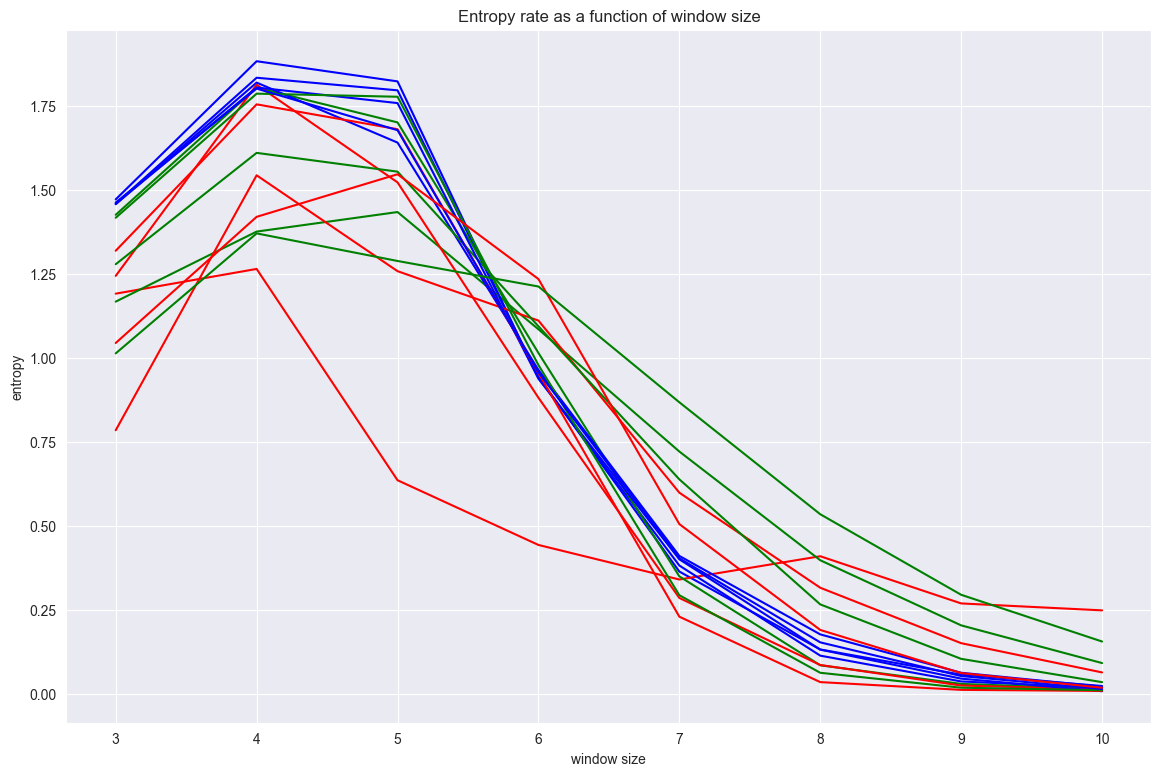

In [5]:
fig, ax = plt.subplots(figsize=(14, 9))
for i in range(5):
    ax.plot(range(3,11), rand_walk_vec[i], label='random walk', color= 'blue')
    ax.plot(range(3,11), arma_vec[i], label='arma(10, 5)', color = 'red')
    ax.plot(range(3,11), cos_vec[i], label='cos with trend', color = 'green')
ax.set_title('Entropy rate as a function of window size')
ax.set_xlabel('window size')
ax.set_ylabel('entropy')
ax.grid(True)
plt.show()

In [20]:
A = np.array([[0.5, 1/4, 0, 1/4, 0, 0],
              [0,0,1/3,0,1/6,1/2],
              [1/2,1/3,0,1/6,0,0],
              [0,0,1/6,0,1/3,1/2],
              [1/2, 1/6,0,1/3,0,0],
              [0,0,1/4,0,1/4,1/2]])
mu = [1/4,1/8,1/8,1/8,1/8,1/4]
entropy_rate(A)

(2.5, 1.4795739585136225)

In [21]:
ts_ser = []
for i in range(100):
    ts_ser.append(permutation_entropy_rate(generate_rw(1000), 3))
pd.DataFrame(ts_ser)

,0
0,2.615832
1,2.631035
2,2.616319
3,2.620853
4,2.616376
...,...
95,2.617269
96,2.614428
97,2.610044
98,2.605962


In [23]:
h = 0
for i in range(6):
    a = 0
    for j in range(6):
        a+= A[i][j]*(np.log2(A[i][j]) if A[i][j]!=0 else 0)
    h+=mu[i]*a
h

-1.4795739585136225

In [25]:
rw = generate_rw(1000)

In [27]:
A = compute_transition_matrix(permutation_series(rw, 3))

In [32]:
matrix_dot = A.copy()
for _ in range(5):
    matrix_dot = np.dot(matrix_dot, matrix_dot)
mu = np.mean(matrix_dot, axis=0)

In [33]:
mu

array([0.24676879, 0.12431546, 0.12637107, 0.12442251, 0.12236691,
       0.25575526])

In [34]:
h = 0
for i in range(6):
    a = 0
    for j in range(6):
        a+= A[i][j]*(np.log2(A[i][j]) if A[i][j]!=0 else 0)
    h+=mu[i]*a
h

-1.4829092335378506